In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import random
import os

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

DATA_DIR = "/kaggle/input/competitions/urban-elements-re-id-challenge-2026/Urban2026"

print("Data directory:", DATA_DIR)
print("Files:", os.listdir(DATA_DIR))

files = [
    "train.csv",
    "train_classes.csv",
    "query.csv",
    "query_classes.csv",
    "test.csv",
    "test_classes.csv",
    "sample_submission.csv",
]

for file in files:
    path = os.path.join(DATA_DIR, file)
    df = pd.read_csv(path)

    print("\n" + "=" * 80)
    print(f"📄 {file}")
    print(f"Shape: {df.shape}")
    print(f"Columns: {df.columns.tolist()}")
    display(df.head())

Data directory: /kaggle/input/competitions/urban-elements-re-id-challenge-2026/Urban2026
Files: ['sample_submission.csv', 'image_test', 'query.csv', 'train_classes.csv', 'image_query', 'test_classes.csv', 'image_train', 'query_classes.csv', 'train.csv', 'test.csv']

📄 train.csv
Shape: (11175, 3)
Columns: ['cameraID', 'imageName', 'Corresponding Indexes']


,cameraID,imageName,Corresponding Indexes
0,c001,000001.jpg,680
1,c001,000002.jpg,164
2,c001,000003.jpg,218
3,c001,000004.jpg,160
4,c001,000005.jpg,684



📄 train_classes.csv
Shape: (11175, 4)
Columns: ['cameraID', 'imageName', 'Corresponding Indexes', 'Class']


,cameraID,imageName,Corresponding Indexes,Class
0,c001,000001.jpg,680,RubbishBins
1,c001,000002.jpg,164,Container
2,c001,000003.jpg,218,trafficsignal
3,c001,000004.jpg,160,Container
4,c001,000005.jpg,684,trafficsignal



📄 query.csv
Shape: (928, 2)
Columns: ['cameraID', 'imageName']


...

,cameraID,imageName
0,c003,000001.jpg
1,c001,000002.jpg
2,c003,000003.jpg
3,c002,000004.jpg
4,c003,000005.jpg



📄 test_classes.csv
Shape: (2844, 3)
Columns: ['cameraID', 'imageName', 'Class']


,cameraID,imageName,Class
0,c003,000001.jpg,RubbishBins
1,c001,000002.jpg,trafficsignal
2,c003,000003.jpg,trafficsignal
3,c002,000004.jpg,Container
4,c003,000005.jpg,trafficsignal



📄 sample_submission.csv
Shape: (928, 2)
Columns: ['imageName', 'Corresponding Indexes']


,imageName,Corresponding Indexes
0,000001.jpg,1603 84 285 2152 2502 820 1221 941 106 1380 15...
1,000002.jpg,2044 85 2501 1934 987 556 635 1656 312 547 283...
2,000003.jpg,937 1747 2796 708 918 1879 2686 2609 700 889 1...
3,000004.jpg,12 79 2305 1452 1067 2286 140 1055 1076 2294 6...
4,000005.jpg,1801 1631 2277 529 617 1334 1561 757 499 2422 ...


In [2]:
import torch
from PIL import Image

seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

torch.use_deterministic_algorithms(True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

TRAIN_DIR = os.path.join(DATA_DIR, "image_train")
QUERY_DIR = os.path.join(DATA_DIR, "image_query")
TEST_DIR = os.path.join(DATA_DIR, "image_test")

print("=" * 70)
print("Devices", device)

if torch.cuda.is_available():
    print("GPU", torch.cuda.get_device_name(0))
    print("CUDA", torch.version.cuda)

print("=" * 70)
print("DATA_DIR", DATA_DIR)

print("\nDirectories:")
for name, path in [
    ("TRAIN_DIR", TRAIN_DIR),("QUERY_DIR", QUERY_DIR),("TEST_DIR", TEST_DIR),
]:
    files = [
        f for f in os.listdir(path)
        if f.lower().endswith(".jpg")
    ]
    print(f"{name:>6}:{len(files)}")

print("\nCSV files")
for f in [
    "train.csv",
    "train_classes.csv",
    "query.csv",
    "query_classes.csv",
    "test.csv",
    "test_classes.csv",
    "sample_submission.csv",
]:
    path = os.path.join(DATA_DIR, f)
    print(f"{f:25s} {os.path.exists(path)}")

Devices cpu
DATA_DIR /kaggle/input/competitions/urban-elements-re-id-challenge-2026/Urban2026

Directories:
TRAIN_DIR:11175
QUERY_DIR:928
TEST_DIR:2844

CSV files
train.csv                 True
train_classes.csv         True
query.csv                 True
query_classes.csv         True
test.csv                  True
test_classes.csv          True
sample_submission.csv     True


In [3]:
# Load CSV Files

train = pd.read_csv(
    os.path.join(DATA_DIR, "train.csv")
)

train_classes = pd.read_csv(
    os.path.join(DATA_DIR, "train_classes.csv")
)

query = pd.read_csv(
    os.path.join(DATA_DIR, "query.csv")
)

query_classes = pd.read_csv(
    os.path.join(DATA_DIR, "query_classes.csv")
)

test = pd.read_csv(
    os.path.join(DATA_DIR, "test.csv")
)

test_classes = pd.read_csv(
    os.path.join(DATA_DIR, "test_classes.csv")
)

sample_submission = pd.read_csv(
    os.path.join(DATA_DIR, "sample_submission.csv")
)

print("=" * 70)
print("Shapes")
print("=" * 70)

print(f"train:             {train.shape}")
print(f"train_classes:     {train_classes.shape}")
print(f"query:             {query.shape}")
print(f"query_classes:     {query_classes.shape}")
print(f"test:              {test.shape}")
print(f"test_classes:      {test_classes.shape}")
print(f"sample_submission: {sample_submission.shape}")

print("\n" + "=" * 70)
print("Columns")
print("=" * 70)

for name, df in [
    ("train", train),
    ("train_classes", train_classes),
    ("query", query),
    ("query_classes", query_classes),
    ("test", test),
    ("test_classes", test_classes),
    ("sample_submission", sample_submission),
]:
    print(f"{name:20s}: {list(df.columns)}")

print("\n" + "=" * 70)
print("Train")
print("=" * 70)

display(train.head())

print("\n" + "=" * 70)
print("Train Classes")
print("=" * 70)

display(train_classes.head())

print("\n" + "=" * 70)
print("Query")
print("=" * 70)

display(query.head())

print("\n" + "=" * 70)
print("Test")
print("=" * 70)

display(test.head())

print("\n" + "=" * 70)
print("Sample Submission")
print("=" * 70)

display(sample_submission.head())

Shapes
train:             (11175, 3)
train_classes:     (11175, 4)
query:             (928, 2)
query_classes:     (928, 3)
test:              (2844, 2)
test_classes:      (2844, 3)
sample_submission: (928, 2)

Columns
train               : ['cameraID', 'imageName', 'Corresponding Indexes']
train_classes       : ['cameraID', 'imageName', 'Corresponding Indexes', 'Class']
query               : ['cameraID', 'imageName']
query_classes       : ['cameraID', 'imageName', 'Class']
test                : ['cameraID', 'imageName']
test_classes        : ['cameraID', 'imageName', 'Class']
sample_submission   : ['imageName', 'Corresponding Indexes']

Train


,cameraID,imageName,Corresponding Indexes
0,c001,000001.jpg,680
1,c001,000002.jpg,164
2,c001,000003.jpg,218
3,c001,000004.jpg,160
4,c001,000005.jpg,684



Train Classes


,cameraID,imageName,Corresponding Indexes,Class
0,c001,000001.jpg,680,RubbishBins
1,c001,000002.jpg,164,Container
2,c001,000003.jpg,218,trafficsignal
3,c001,000004.jpg,160,Container
4,c001,000005.jpg,684,trafficsignal



Query


,cameraID,imageName
0,c004,000001.jpg
1,c004,000002.jpg
2,c004,000003.jpg
3,c004,000004.jpg
4,c004,000005.jpg



Test


,cameraID,imageName
0,c003,000001.jpg
1,c001,000002.jpg
2,c003,000003.jpg
3,c002,000004.jpg
4,c003,000005.jpg



Sample Submission


,imageName,Corresponding Indexes
0,000001.jpg,1603 84 285 2152 2502 820 1221 941 106 1380 15...
1,000002.jpg,2044 85 2501 1934 987 556 635 1656 312 547 283...
2,000003.jpg,937 1747 2796 708 918 1879 2686 2609 700 889 1...
3,000004.jpg,12 79 2305 1452 1067 2286 140 1055 1076 2294 6...
4,000005.jpg,1801 1631 2277 529 617 1334 1561 757 499 2422 ...


In [4]:
# 3 — Validate Data & Build Train DataFrame

print("=" * 70)
print("1. Checking train.csv vs train_classes.csv")
print("=" * 70)

# Check train.csv and train_classes.csv

for col in ["cameraID", "imageName", "Corresponding Indexes"]:
    same = train[col].astype(str).reset_index(drop=True).equals(
        train_classes[col].astype(str).reset_index(drop=True)
    )
    print(f"{col:25s}: {same}")


print("\n" + "=" * 70)
print("2. Checking query.csv vs query_classes.csv")
print("=" * 70)

for col in ["cameraID", "imageName"]:
    same = query[col].astype(str).reset_index(drop=True).equals(
        query_classes[col].astype(str).reset_index(drop=True)
    )
    print(f"{col:25s}: {same}")


print("\n" + "=" * 70)
print("3. Checking test.csv vs test_classes.csv")
print("=" * 70)

for col in ["cameraID", "imageName"]:
    same = test[col].astype(str).reset_index(drop=True).equals(
        test_classes[col].astype(str).reset_index(drop=True)
    )
    print(f"{col:25s}: {same}")

train_df = train_classes.copy()

# Explicitly create identity column
train_df["identity"] = train_df["Corresponding Indexes"]

# Create image path
train_df["image_path"] = train_df["imageName"].apply(
    lambda x: os.path.join(TRAIN_DIR, x)
)

print("\n" + "=" * 70)
print("4. Train dataframe")
print("=" * 70)

print("Columns:")
print(train_df.columns.tolist())

display(train_df.head())

print("\n" + "=" * 70)
print("5. Checking train image files")
print("=" * 70)

missing = ~train_df["image_path"].apply(os.path.exists)

print("Missing train images:", missing.sum())

if missing.sum() > 0:
    print("\nFirst missing images:")
    display(
        train_df.loc[
            missing,
            ["cameraID", "imageName", "identity", "Class", "image_path"]
        ].head(10)
    )

print("\n" + "=" * 70)
print("6. Identity statistics")
print("=" * 70)

identity_counts = train_df["identity"].value_counts()

print("Number of identities:", train_df["identity"].nunique())
print("Minimum images / identity:", identity_counts.min())
print("Maximum images / identity:", identity_counts.max())
print("Mean images / identity:", round(identity_counts.mean(), 2))
print("Median images / identity:", identity_counts.median())

print("\n" + "=" * 70)
print("7. Class statistics")
print("=" * 70)

display(
    train_df["Class"]
    .value_counts()
    .rename_axis("Class")
    .reset_index(name="Count")
)

print("\n" + "=" * 70)
print("8. Camera statistics")
print("=" * 70)

display(
    train_df["cameraID"]
    .value_counts()
    .sort_index()
    .rename_axis("cameraID")
    .reset_index(name="Count")
)

1. Checking train.csv vs train_classes.csv
cameraID                 : True
imageName                : True
Corresponding Indexes    : True

2. Checking query.csv vs query_classes.csv
cameraID                 : True
imageName                : True

3. Checking test.csv vs test_classes.csv
cameraID                 : True
imageName                : True

4. Train dataframe
Columns:
['cameraID', 'imageName', 'Corresponding Indexes', 'Class', 'identity', 'image_path']


,cameraID,imageName,Corresponding Indexes,Class,identity,image_path
0,c001,000001.jpg,680,RubbishBins,680,/kaggle/input/competitions/urban-elements-re-i...
1,c001,000002.jpg,164,Container,164,/kaggle/input/competitions/urban-elements-re-i...
2,c001,000003.jpg,218,trafficsignal,218,/kaggle/input/competitions/urban-elements-re-i...
3,c001,000004.jpg,160,Container,160,/kaggle/input/competitions/urban-elements-re-i...
4,c001,000005.jpg,684,trafficsignal,684,/kaggle/input/competitions/urban-elements-re-i...



5. Checking train image files
Missing train images: 0

6. Identity statistics
Number of identities: 1088
Minimum images / identity: 1
Maximum images / identity: 64
Mean images / identity: 10.27
Median images / identity: 9.0

7. Class statistics


,Class,Count
0,trafficsignal,7568
1,Crosswalk,1532
2,Container,1189
3,RubbishBins,886



8. Camera statistics


,cameraID,Count
0,c001,3799
1,c002,3559
2,c003,3817


In [5]:
# Building cross-camera validation set
from collections import defaultdict

QUERY_CAMERA = "c001"
GALLERY_CAMERAS = ["c002", "c003"]

val_query_df = train_df[train_df["cameraID"] == QUERY_CAMERA].copy()
val_gallery_df = train_df[train_df["cameraID"].isin(GALLERY_CAMERAS)].copy()

query_ids = set(val_query_df.identity)
gallery_ids = set(val_gallery_df.identity)

valid_ids = query_ids.intersection(gallery_ids)

print("Query camera:", QUERY_CAMERA)
print("Query camera:", GALLERY_CAMERAS)
print("\nIdentiteis:")
print("In query camera:", len(query_ids))
print("In gallery camera:", len(gallery_ids))
print("Valid camera:", len(valid_ids))

# Fliter
val_query_df = val_query_df[val_query_df["identity"].isin(valid_ids)].copy()
val_gallery_df = val_gallery_df[val_gallery_df["identity"].isin(valid_ids)].copy()

# Reset index
val_query_df = val_query_df.reset_index(drop = True)
val_gallery_df = val_gallery_df.reset_index(drop = True)

print("\nValidation query images:", len(val_query_df))
print("Validation gallery images:", len(val_gallery_df))
print("Validation identities:",
     val_query_df["identity"].nunique())

print("\nQuery class distribution:")
display(
    val_query_df["Class"]
    .value_counts()
    .rename_axis("Class")
    .reset_index(name="Count")
)

print("\nGallery class distribution:")
display(
    val_gallery_df["Class"]
    .value_counts()
    .rename_axis("Class")
    .reset_index(name="Count")
)

gallery_identity_set = set(
    val_gallery_df["identity"]
)

query_without_positive = val_query_df[
    ~val_query_df["identity"].isin(gallery_identity_set)
]

print("\nQueries without positive gallery image:",
      len(query_without_positive))

print("\n" + "=" * 70)
print("Validation query examples")
print("=" * 70)

display(
    val_query_df[
        ["cameraID", "imageName", "identity", "Class"]
    ].head(10)
)

print("\n" + "=" * 70)
print("Validation gallery examples")
print("=" * 70)

display(
    val_gallery_df[
        ["cameraID", "imageName", "identity", "Class"]
    ].head(10)
)

Query camera: c001
Query camera: ['c002', 'c003']

Identiteis:
In query camera: 1013
In gallery camera: 1074
Valid camera: 999

Validation query images: 3779
Validation gallery images: 7155
Validation identities: 999

Query class distribution:


,Class,Count
0,trafficsignal,2651
1,Crosswalk,503
2,Container,340
3,RubbishBins,285



Gallery class distribution:


,Class,Count
0,trafficsignal,4769
1,Crosswalk,1019
2,Container,777
3,RubbishBins,590



Queries without positive gallery image: 0

Validation query examples


,cameraID,imageName,identity,Class
0,c001,000001.jpg,680,RubbishBins
1,c001,000002.jpg,164,Container
2,c001,000003.jpg,218,trafficsignal
3,c001,000004.jpg,160,Container
4,c001,000005.jpg,684,trafficsignal
5,c001,000009.jpg,1055,trafficsignal
6,c001,000011.jpg,934,trafficsignal
7,c001,000014.jpg,390,Container
8,c001,000018.jpg,165,trafficsignal
9,c001,000023.jpg,431,Container



Validation gallery examples


,cameraID,imageName,identity,Class
0,c003,000006.jpg,1036,trafficsignal
1,c003,000007.jpg,659,trafficsignal
2,c002,000008.jpg,569,trafficsignal
3,c003,000010.jpg,334,trafficsignal
4,c003,000012.jpg,195,trafficsignal
5,c002,000013.jpg,548,Crosswalk
6,c003,000015.jpg,381,trafficsignal
7,c003,000016.jpg,847,trafficsignal
8,c002,000017.jpg,987,trafficsignal
9,c003,000019.jpg,988,Container


Image size statistics
Number of images: 11175

Width:
  min    = 6
  max    = 1920
  mean   = 131.61
  median = 39.00

Height:
  min    = 6
  max    = 781
  mean   = 67.87
  median = 43.00

Short side:
  <=  10px:   177 (  1.58%)
  <=  20px:  2777 ( 24.85%)
  <=  30px:  5149 ( 46.08%)
  <=  40px:  6584 ( 58.92%)
  <=  50px:  7535 ( 67.43%)
  <= 100px:  9862 ( 88.25%)

Random training images


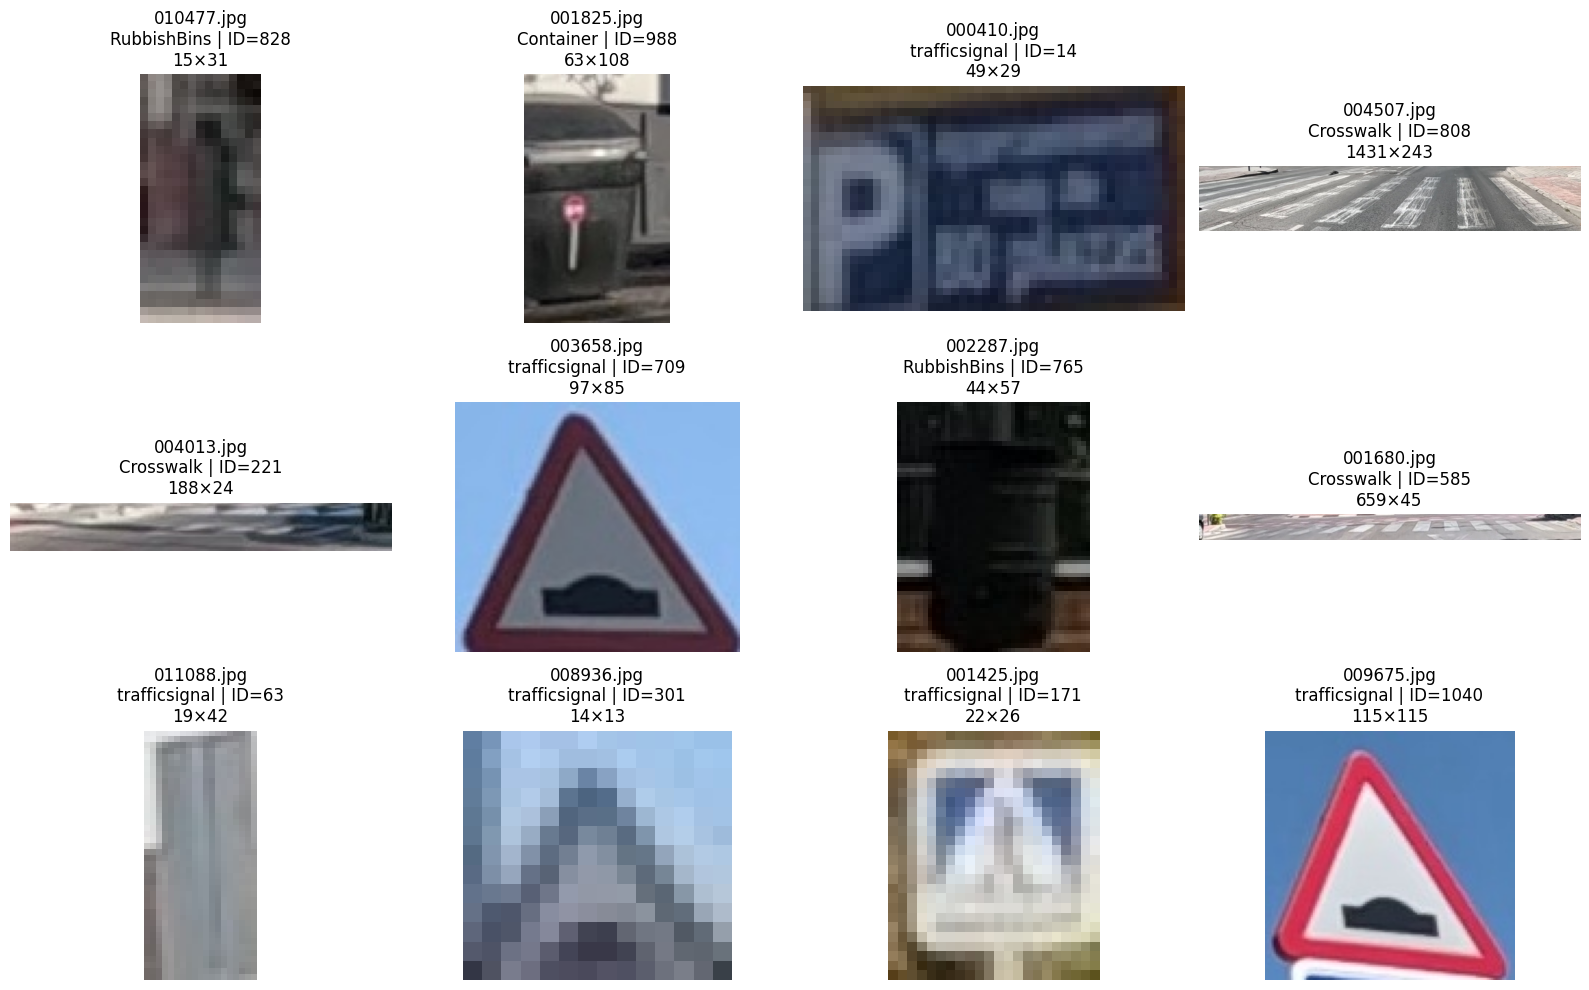

In [6]:
from PIL import Image
import matplotlib.pyplot as plt

print("=" * 70)
print("Image size statistics")
print("=" * 70)

widths = []
heights = []

for path in train_df["image_path"]:
    try:
        with Image.open(path) as img:
            w, h = img.size
            widths.append(w)
            heights.append(h)
    except Exception as e:
        print("Error:", path, e)

widths = np.array(widths)
heights = np.array(heights)

short_sides = np.minimum(widths, heights)

print(f"Number of images: {len(widths)}")

print("\nWidth:")
print(f"  min    = {widths.min()}")
print(f"  max    = {widths.max()}")
print(f"  mean   = {widths.mean():.2f}")
print(f"  median = {np.median(widths):.2f}")

print("\nHeight:")
print(f"  min    = {heights.min()}")
print(f"  max    = {heights.max()}")
print(f"  mean   = {heights.mean():.2f}")
print(f"  median = {np.median(heights):.2f}")

print("\nShort side:")
for x in [10, 20, 30, 40, 50, 100]:
    ratio = np.mean(short_sides <= x) * 100
    print(f"  <= {x:3d}px: {np.sum(short_sides <= x):5d} "
          f"({ratio:6.2f}%)")

print("\n" + "=" * 70)
print("Random training images")
print("=" * 70)

random.seed(42)

sample_indices = random.sample(
    range(len(train_df)),
    12
)

fig, axes = plt.subplots(3, 4, figsize=(16, 10))

for ax, idx in zip(axes.flatten(), sample_indices):

    row = train_df.iloc[idx]

    try:
        img = Image.open(row["image_path"]).convert("RGB")

        ax.imshow(img)
        ax.set_title(
            f'{row["imageName"]}\n'
            f'{row["Class"]} | ID={row["identity"]}\n'
            f'{img.size[0]}×{img.size[1]}'
        )

    except Exception as e:
        ax.set_title(f"Error\n{e}")

    ax.axis("off")

plt.tight_layout()
plt.show()

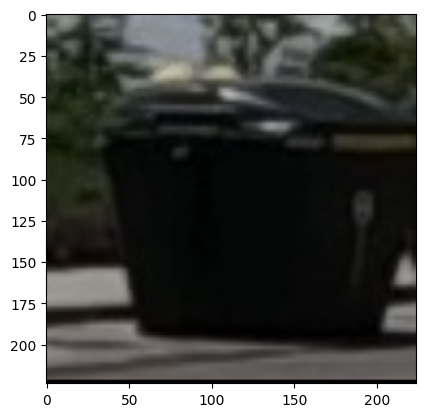

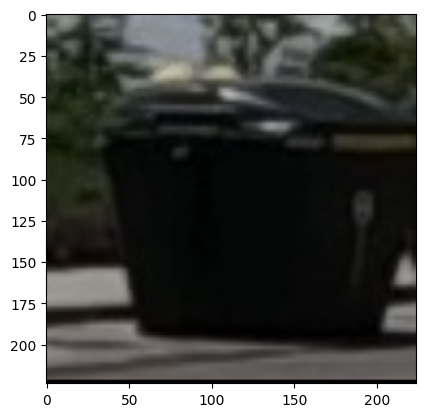

In [7]:
from torch.utils.data import Dataset
from torch.utils.data import DataLoader
from torchvision import transforms

erase_p = 0.5
erase_scale = (0.02, 0.2)

#training_transform = transforms.Compose([transforms.RandomErasing(erase_p,erase_scale)])
training_transform = transforms.Compose([])
validation_transform = transforms.Compose([])

class ReIDDataset(Dataset):
    def __init__(self, dataframe, transform = None):
        self.df = dataframe
        self.tf = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image_path = row["image_path"]
        image = Image.open(image_path)

        ## scale
        width, height = image.size
        scale = 224 / max(width, height)
        new_width = width * scale
        new_height = height * scale

        ## padding
        padding_width = 224 - round(new_width)
        padding_height = 224 - round(new_height)

        left = padding_width // 2
        right = padding_width - left

        top = padding_height // 2
        bottom = padding_height - top

        ## ToTensor

        transform = transforms.Compose([transforms.Resize((round(new_height), round(new_width))),
                                           transforms.Pad((left, top, right, bottom)),
                                           transforms.ToTensor()])
            
        image = transform(image)
        if self.tf is not None:
            image = self.tf(image)

        identity = row["identity"]
        return image, identity

train_dataset = ReIDDataset(train_df, transform = training_transform)
val_query_dataset = ReIDDataset(val_query_df, transform = validation_transform)
val_gallery_dataset = ReIDDataset(val_gallery_df, transform = validation_transform)
train_loader = DataLoader(train_dataset, batch_size = 32)

#images, identities = next(iter(train_loader))
images1, _ = next(iter(train_loader))
images2, _ = next(iter(train_loader))

plt.figure()
plt.imshow(images1[1].permute(1, 2, 0))
plt.show()

plt.figure()
plt.imshow(images2[1].permute(1, 2, 0))
plt.show()

In [8]:
from torchvision import models
import torch.nn.functional as F

model = models.resnet18()

weights_path = "/kaggle/input/models/npri678/resnet18-f37072fd-pth/pytorch/default/1/resnet18-f37072fd.pth"
state_dict = torch.load(weights_path, map_location="cpu")
model.load_state_dict(state_dict)

# remove the last layer
model.fc = torch.nn.Identity()
model.train()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.0001
)

print(model.training)
print(model.fc)

True
Identity()


In [9]:
model.eval()

print(model.training)
print(model.fc)

False
Identity()


In [10]:
# validation DataLoader

val_query_df.head()
val_query_dataset = ReIDDataset(val_query_df)
val_gallery_dataset = ReIDDataset(val_gallery_df)

val_query_loader = DataLoader(
    val_query_dataset,
    batch_size=32,
    shuffle=False
)

val_gallery_loader = DataLoader(
    val_gallery_dataset,
    batch_size=32,
    shuffle=False
)

unique_identities = []
for images, identities in train_loader:
    unique_identities += [len(identities.unique())]
unique_identities = np.array(unique_identities)
unique_identities_mean = unique_identities.mean()
print(unique_identities_mean)

31.397142857142857


In [11]:
# P-K sampling

#identity_counts = train_df.groupby("identity").size()
#
#for epoch in range(5):
#    for batch in range(100):
#        
#        optimizer.zero_grad()
#        valid_identities = identity_counts[identity_counts >= 4].sample(4)
#    
#        batch_df = pd.DataFrame()
#        
#        for i in range(len(valid_identities.index)):
#            ids = train_df[train_df["identity"] == valid_identities.index[i]].sample(4)
#            batch_df = pd.concat((batch_df, ids), axis = 0)
#            
#        #print(batch_df.shape)
#        #print(batch_df["identity"].value_counts())
#        
#        train_dataset = ReIDDataset(batch_df, transform = training_transform) 
#        train_loader = DataLoader(train_dataset, batch_size = batch_df.shape[0])
#        images, identities = next(iter(train_loader))
#        #print(identities)
#        #print(identities.unique())
#        #print(images.shape)
#
#        features = model(images)
#        
#        features = F.normalize(features, dim=1)
#        similarity = features @ features.T
#        
#        same_identity = identities.unsqueeze(1) == identities.unsqueeze(0)
#        
#        loss = torch.where(same_identity, 1 - similarity, similarity)
#        
#        mask = torch.eye(batch_df.shape[0], batch_df.shape[0]) != 1
#        loss_without_self = loss[mask]
#        loss = loss_without_self.mean()
#            
#        loss.backward()
#        optimizer.step()
#        
#        print(loss)
#    break
#break

In [12]:
# Batch Hard Triplet Loss

identity_counts = train_df.groupby("identity").size()

model.train()

for epoch in range(5):
    for batch in range(100):
        
        optimizer.zero_grad()
        valid_identities = identity_counts[identity_counts >= 4].sample(4)
    
        batch_df = pd.DataFrame()
        
        for i in range(len(valid_identities.index)):
            ids = train_df[train_df["identity"] == valid_identities.index[i]].sample(4)
            batch_df = pd.concat((batch_df, ids), axis = 0)
            
        #print(batch_df.shape)
        #print(batch_df["identity"].value_counts())
        
        train_dataset = ReIDDataset(batch_df, transform = training_transform) 
        train_loader = DataLoader(train_dataset, batch_size = batch_df.shape[0])
        images, identities = next(iter(train_loader))
        #print(identities)
        #print(identities.unique())
        #print(images.shape)

        features = model(images)
        
        features = F.normalize(features, dim=1)
        similarity = features @ features.T
        
        same_identity = identities.unsqueeze(1) == identities.unsqueeze(0)

        distance = 1 - similarity
        
        #loss = torch.where(same_identity, 1 - similarity, similarity)
        
        mask = torch.eye(batch_df.shape[0], batch_df.shape[0]) != 1

        ## hardest_positive
        positive_mask = same_identity & mask
        #print(positive_mask)
        
        hard_positive_distance = torch.where(
            positive_mask, distance, -1e9)
        hardest_positive = torch.argmax(hard_positive_distance, dim=1)
        hardest_positive_distance = distance[torch.arange(distance.shape[0]),hardest_positive]
        
        #print(hardest_positive_distance)
        #print(hardest_positive_distance.shape)

        ## hardest_negtive
        negtive_mask = ~same_identity & mask
        #print(negtive_mask)
        
        hard_negtive_distance = torch.where(
            negtive_mask, distance, 1e10)
        #print(hard_negtive_distance)
        hardest_negtive = torch.argmin(hard_negtive_distance, dim=1)
        hardest_negative_distance = distance[torch.arange(distance.shape[0]),hardest_negtive]
        
        #print(hardest_negtive_distance)
        #print(hardest_negative_distance.shape)

        ## Triplet Loss

        margin = 0.2
        loss = F.relu(hardest_positive_distance 
                   - hardest_negative_distance + margin)
        
        #loss_without_self = loss[mask]
        loss = loss.mean()
            
        loss.backward()
        optimizer.step()
        
        print(loss)

tensor(0.1860, grad_fn=<MeanBackward0>)
tensor(0.1173, grad_fn=<MeanBackward0>)
tensor(0.2338, grad_fn=<MeanBackward0>)
tensor(0.1923, grad_fn=<MeanBackward0>)
tensor(0.1656, grad_fn=<MeanBackward0>)
tensor(0.1242, grad_fn=<MeanBackward0>)
tensor(0.1515, grad_fn=<MeanBackward0>)
tensor(0.2293, grad_fn=<MeanBackward0>)
tensor(0.1962, grad_fn=<MeanBackward0>)
tensor(0.2068, grad_fn=<MeanBackward0>)
tensor(0.1296, grad_fn=<MeanBackward0>)
tensor(0.1627, grad_fn=<MeanBackward0>)
tensor(0.1593, grad_fn=<MeanBackward0>)
tensor(0.1714, grad_fn=<MeanBackward0>)
tensor(0.1994, grad_fn=<MeanBackward0>)
tensor(0.2157, grad_fn=<MeanBackward0>)
tensor(0.2457, grad_fn=<MeanBackward0>)
tensor(0.2715, grad_fn=<MeanBackward0>)
tensor(0.2675, grad_fn=<MeanBackward0>)
tensor(0.1847, grad_fn=<MeanBackward0>)
tensor(0.0893, grad_fn=<MeanBackward0>)
tensor(0.1468, grad_fn=<MeanBackward0>)
tensor(0.1939, grad_fn=<MeanBackward0>)
tensor(0.1608, grad_fn=<MeanBackward0>)
tensor(0.0969, grad_fn=<MeanBackward0>)


In [13]:
model.eval()
print(model.training)

False


In [14]:
query_features = []
gallery_features = []

for images, identities in val_query_loader:
    with torch.no_grad():
        features = model(images)
    query_features.append(features)
query_features = torch.cat(query_features, dim =0)

print(query_features.shape)

for images, identities in val_gallery_loader:
    with torch.no_grad():
        features = model(images)
        
    gallery_features.append(features)
gallery_features = torch.cat(gallery_features,dim = 0)

query_features = F.normalize(query_features, dim=1)
gallery_features = F.normalize(gallery_features, dim=1)

similarity = query_features @ gallery_features.T

print(query_features.shape)
print(gallery_features.shape)
print(similarity.shape)

torch.Size([3779, 512])
torch.Size([3779, 512])
torch.Size([7155, 512])
torch.Size([3779, 7155])


In [15]:
print(query_features.shape)
print(gallery_features.shape)
print(similarity.shape)

print("=" * 70)
print("Accuracy Ranking")
print("=" * 70)

# Top 1 accurary
top1_indices = torch.argmax(similarity, dim = 1)
predicted_ids = val_gallery_df.iloc[top1_indices]["identity"].values

correct = predicted_ids == val_query_df["identity"].values
rank1_accuracy = correct.mean()

print("Rank 1 accuracy :", rank1_accuracy)

gallery_identities = val_gallery_df["identity"].values

# Top 5 accurary
top5_values, top5_indices = torch.topk(similarity, k=5, dim=1)

query_identities = val_query_df["identity"].values

predicted_ids = gallery_identities[top5_indices.numpy()]
correct_matrix = predicted_ids == query_identities[:, None]
correct = correct_matrix.any(axis = 1)
rank5_accuracy = correct.mean()

print("Rank 5 accuracy :", rank5_accuracy)
# check Top 10 accurary
top10_values, top10_indices = torch.topk(similarity, k=10, dim=1)
query_identities = val_query_df["identity"].values

predicted_ids = gallery_identities[top10_indices.numpy()]
correct_matrix = predicted_ids == query_identities[:, None]
correct = correct_matrix.any(axis = 1)
rank10_accuracy = correct.mean()

print("Rank 10 accuracy :", rank10_accuracy)

torch.Size([3779, 512])
torch.Size([7155, 512])
torch.Size([3779, 7155])
Accuracy Ranking
Rank 1 accuracy : 0.5093940195819
Rank 5 accuracy : 0.7372320719767134
Rank 10 accuracy : 0.8131780894416513


Class
Container        0.350000
Crosswalk        0.248509
RubbishBins      0.452632
trafficsignal    0.585439
Name: correct, dtype: float64
torch.Size([3, 224, 224])
torch.Size([224, 224, 3])


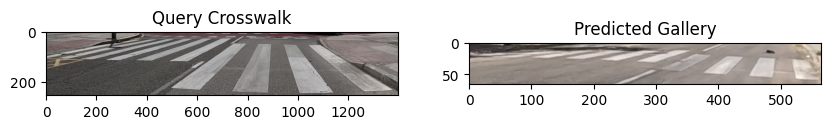

In [16]:
# Performance of the test results for classes
top1_gallery = val_gallery_df.iloc[top1_indices]

predicted_ids = val_gallery_df.iloc[top1_indices]["identity"].values
correct1 = predicted_ids == val_query_df["identity"].values

result = val_query_df[["Class"]].copy()
result["identity"] = val_query_df[["identity"]].copy()
result["correct"] = correct1
result["predicted_ids"] = val_gallery_df.iloc[top1_indices]["identity"].values
result["image_path"] = val_query_df["image_path"].values

class_accuracy1 = result.groupby("Class")["correct"].mean()

print(class_accuracy1)

# Error Analysis

crosswalk_df = train_df[train_df["Class"] == "Crosswalk"]
traffic_df = train_df[train_df["Class"] == "trafficsignal"]

crosswalk_sample = crosswalk_df.sample(1)
traffic_sample = traffic_df.sample(1)

#plt.figure(figsize=(10, 5))
#plt.subplot(1,2,1)
#plt.imshow(Image.open(crosswalk_sample["image_path"].iloc[0]))

#plt.subplot(1,2,2)
#plt.imshow(Image.open(traffic_sample["image_path"].iloc[0]))

#plt.show()

crosswalk_dataset = ReIDDataset(crosswalk_sample)
traffic_dataset = ReIDDataset(traffic_sample)

image, identity = crosswalk_dataset[0]
print(image.shape)

image = image.permute(1,2,0)
print(image.shape)

#plt.figure(figsize=(10, 5))
#plt.imshow(image)
#plt.show()

# Comparison of Examples of Errors

wrong_crosswalk_df = result[
    (result["correct"] == False) &
    (result["Class"] == "Crosswalk")
]

wrong_crosswalk_sample = wrong_crosswalk_df.sample(1)

predicted_identity = wrong_crosswalk_sample["predicted_ids"].iloc[0]

# Find the gallery image predicted by the model
predicted_gallery = val_gallery_df[
    val_gallery_df["identity"] == predicted_identity
]

plt.figure(figsize=(10, 5))

# Query image
plt.subplot(1, 2, 1)
plt.imshow(
    Image.open(wrong_crosswalk_sample["image_path"].iloc[0])
)
plt.title("Query Crosswalk")

# Predicted gallery image
plt.subplot(1, 2, 2)
plt.imshow(
    Image.open(predicted_gallery["image_path"].iloc[0])
)
plt.title("Predicted Gallery")

plt.show()

In [17]:
# Analyze the relationship between cropping and accuracy.

short_sides = []

for image_path in val_query_df["image_path"]:
    image = Image.open(image_path)
    width, height = image.size
    short_sides.append(min(width, height))
#print(len(short_sides))

result["short_sides"] = short_sides
#print(result.head)
crosswalk_result = result[result["Class"] == "Crosswalk"].copy()
#print(crosswalk_result.head)

short_count1 = 0
short_count2 = 0
short_count3 = 0
short_count4 = 0
for i in range(len(crosswalk_result["short_sides"])):
    if crosswalk_result["short_sides"].iloc[i] <=20:
        short_count1 += 1
    elif 20 < crosswalk_result["short_sides"].iloc[i] <=40:
        short_count2 += 1
    elif 40 < crosswalk_result["short_sides"].iloc[i] <=80:
        short_count3 += 1
    else:
        short_count4 += 1
        
print(short_count1)
print(short_count2)
print(short_count3)
print(short_count4)

crosswalk_result["short_side_group"] = 0
crosswalk_result.loc[crosswalk_result["short_sides"] <= 20, "short_side_group"] = 1
crosswalk_result.loc[(crosswalk_result["short_sides"] > 20) & (crosswalk_result["short_sides"] <= 40), "short_side_group"] = 2
crosswalk_result.loc[(40 < crosswalk_result["short_sides"]) & (crosswalk_result["short_sides"] <= 80), "short_side_group"] = 3
crosswalk_result.loc[80 < crosswalk_result["short_sides"], "short_side_group"] = 4

crosswalk_accuracy = crosswalk_result.groupby("short_side_group")["correct"].mean()

print(crosswalk_accuracy)

49
113
145
196
short_side_group
1    0.265306
2    0.256637
3    0.213793
4    0.265306
Name: correct, dtype: float64


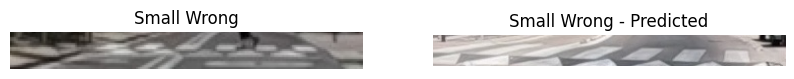

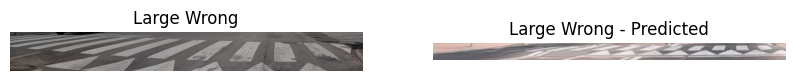

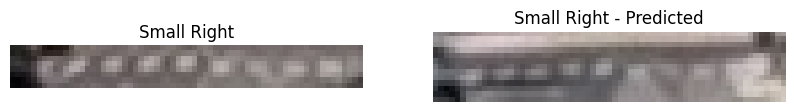

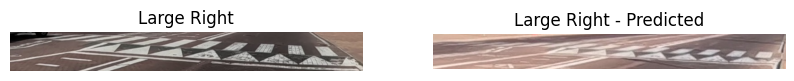

In [18]:
crosswalk_small = crosswalk_result[
    crosswalk_result["short_side_group"] == 1
].copy()

crosswalk_large = crosswalk_result[
    crosswalk_result["short_side_group"] == 4
].copy()

# -------------------------
# Small: wrong / right
# -------------------------

crosswalk_small_wrong = crosswalk_small[
    crosswalk_small["correct"] == False
].sample(1)

crosswalk_small_right = crosswalk_small[
    crosswalk_small["correct"] == True
].sample(1)

# -------------------------
# Large: wrong / right
# -------------------------

crosswalk_large_wrong = crosswalk_large[
    crosswalk_large["correct"] == False
].sample(1)

crosswalk_large_right = crosswalk_large[
    crosswalk_large["correct"] == True
].sample(1)

# -------------------------
# Get predicted identity
# -------------------------

preID_small = crosswalk_small_wrong["predicted_ids"].iloc[0]
preID_large = crosswalk_large_wrong["predicted_ids"].iloc[0]

preID_small_right = crosswalk_small_right["predicted_ids"].iloc[0]
preID_large_right = crosswalk_large_right["predicted_ids"].iloc[0]

# -------------------------
# Find predicted gallery images
# -------------------------

predicted_gallery_small = val_gallery_df[
    val_gallery_df["identity"] == preID_small
]

predicted_gallery_large = val_gallery_df[
    val_gallery_df["identity"] == preID_large
]

predicted_gallery_small_right = val_gallery_df[
    val_gallery_df["identity"] == preID_small_right
]

predicted_gallery_large_right = val_gallery_df[
    val_gallery_df["identity"] == preID_large_right
]

# =========================
# Small + Wrong
# =========================

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(
    Image.open(crosswalk_small_wrong["image_path"].iloc[0])
)
plt.title("Small Wrong")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(
    Image.open(predicted_gallery_small["image_path"].iloc[0])
)
plt.title("Small Wrong - Predicted")
plt.axis("off")

plt.show()


# =========================
# Large + Wrong
# =========================

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(
    Image.open(crosswalk_large_wrong["image_path"].iloc[0])
)
plt.title("Large Wrong")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(
    Image.open(predicted_gallery_large["image_path"].iloc[0])
)
plt.title("Large Wrong - Predicted")
plt.axis("off")

plt.show()


# =========================
# Small + Right
# =========================

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(
    Image.open(crosswalk_small_right["image_path"].iloc[0])
)
plt.title("Small Right")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(
    Image.open(predicted_gallery_small_right["image_path"].iloc[0])
)
plt.title("Small Right - Predicted")
plt.axis("off")

plt.show()


# =========================
# Large + Right
# =========================

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(
    Image.open(crosswalk_large_right["image_path"].iloc[0])
)
plt.title("Large Right")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(
    Image.open(predicted_gallery_large_right["image_path"].iloc[0])
)
plt.title("Large Right - Predicted")
plt.axis("off")

plt.show()

(928, 3)
(2844, 3)


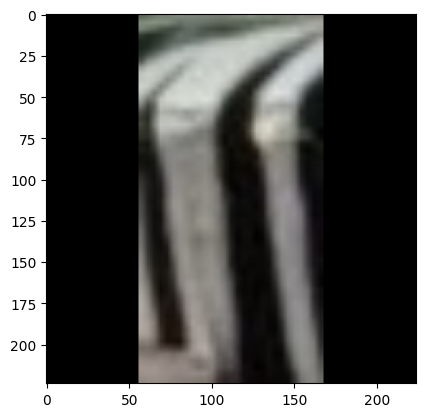

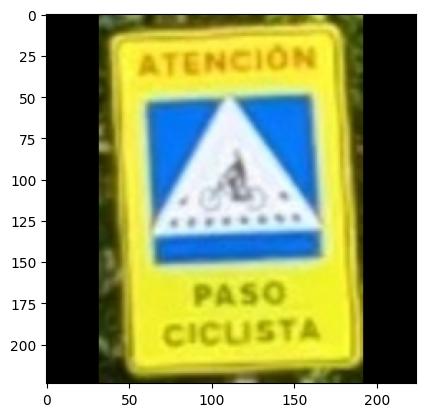

In [30]:
model.eval()

query_df = query.copy()
test_df = test.copy()

query_df["image_path"] = query_df["imageName"].apply(
    lambda x: os.path.join(QUERY_DIR, x)
)
test_df["image_path"] = test_df["imageName"].apply(
    lambda x: os.path.join(TEST_DIR, x)
)

training_transform = transforms.Compose([])
validation_transform = transforms.Compose([])

print(query_df.shape)
print(test_df.shape)

class TestDataset(Dataset):
    def __init__(self, dataframe, transform = None):
        self.df = dataframe
        self.tf = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image_path = row["image_path"]
        image = Image.open(image_path)

        ## scale
        width, height = image.size
        scale = 224 / max(width, height)
        new_width = width * scale
        new_height = height * scale

        ## padding
        padding_width = 224 - round(new_width)
        padding_height = 224 - round(new_height)

        left = padding_width // 2
        right = padding_width - left

        top = padding_height // 2
        bottom = padding_height - top

        ## ToTensor

        transform = transforms.Compose([transforms.Resize((round(new_height), round(new_width))),
                                           transforms.Pad((left, top, right, bottom)),
                                           transforms.ToTensor()])
        
        image = transform(image)
        if self.tf is not None:
            image = self.tf(image)

        return image

query_dataset = TestDataset(query_df, transform = validation_transform)
query_loader = DataLoader(query_dataset, batch_size = 32)
test_dataset = TestDataset(test_df, transform = validation_transform)
test_loader = DataLoader(test_dataset, batch_size = 32)

display(query_dataset)

images1 = next(iter(query_loader))
images2 = next(iter(test_loader))

plt.figure()
plt.imshow(images1[1].permute(1, 2, 0))
plt.show()

plt.figure()
plt.imshow(images2[1].permute(1, 2, 0))
plt.show()

In [31]:
query_all_features = []
test_features = []

for images in query_loader:
    with torch.no_grad():
        features = model(images)
    query_all_features.append(features)
query_all_features = torch.cat(query_all_features, dim =0)

print(query_all_features.shape)

for images in test_loader:
    with torch.no_grad():
        features = model(images)
        
    test_features.append(features)
test_features = torch.cat(test_features,dim = 0)

query_all_features = F.normalize(query_all_features, dim=1)
test_features = F.normalize(test_features, dim=1)

similarity = query_all_features @ test_features.T

print(query_all_features.shape)
print(test_features.shape)
print(similarity.shape)

torch.Size([928, 512])
torch.Size([928, 512])
torch.Size([2844, 512])
torch.Size([928, 2844])


In [54]:
# Top 100 accurary
top100_values, top100_indices = torch.topk(similarity, k=100, dim=1)

print(top100_values.shape)
print(top100_indices.shape)
print(top100_indices.min())
print(top100_indices.max())

submission = sample_submission.copy()
submission["Corresponding Indexes"] = [
    " ".join(map(str, row + 1))
    for row in top100_indices.numpy()
]

submission.to_csv("submission.csv", index=False)
print(submission.head())

print(os.path.exists("submission.csv"))

torch.Size([928, 100])
torch.Size([928, 100])
tensor(0)
tensor(2843)
    imageName                              Corresponding Indexes
0  000001.jpg  1280 106 1083 1525 941 582 2572 1802 1726 2678...
1  000002.jpg  2044 1102 2501 312 2714 2832 550 2790 1934 635...
2  000003.jpg  257 742 1800 2843 338 593 2341 1871 336 2549 1...
3  000004.jpg  598 12 2294 1998 608 1439 864 677 1771 2813 52...
4  000005.jpg  341 1091 1801 564 1561 989 2242 777 1898 1996 ...
True


In [55]:
check = pd.read_csv("submission.csv")

print(check.shape)
print(check.columns.tolist())
print(check.iloc[0])
print(len(check.iloc[0]["Corresponding Indexes"].split()))

(928, 2)
['imageName', 'Corresponding Indexes']
imageName                                                       000001.jpg
Corresponding Indexes    1280 106 1083 1525 941 582 2572 1802 1726 2678...
Name: 0, dtype: object
100
